# NGSO SLS — Live Coverage Explorer (Slice A analysis on a live constellation)

The notebook-01 coverage analysis (n-in-view, max-elevation, availability curves, latitude
profile, elevation sweep) computed on the **live constellation pulled from Spacetime**
(fss01-demo: 150-sat, 10×15, 53°, ~1157 km) instead of a Walker preset.

**Read-only guarantee:** the pull uses `StorageEntityStore`, which wires only
`Store.Get` / `Store.GetEntities` — no write RPC exists on the client. Nothing in this
notebook alters the instance model or provisioning.

**Data source:** live raw Store (default `localhost:9999`, override `SLS_STORE_TARGET`)
with automatic fallback to the textproto dump (`SLS_DUMP_DIR`).


In [1]:
# === Setup & live pull ===
import os, sys, pathlib, datetime
_REPO = pathlib.Path.cwd().resolve()
while _REPO != _REPO.parent and not (_REPO / "ngso_sls").is_dir():
    _REPO = _REPO.parent
if not (_REPO / "ngso_sls").is_dir():                    # cwd outside a checkout:
    _anchor = pathlib.Path("/workspace/spacetime-sls")    # sandbox/host mount anchor
    if (_anchor / "ngso_sls").is_dir():
        _REPO = _anchor
if not (_REPO / "ngso_sls").is_dir():                    # bare runtime (Colab): clone + install
    import subprocess
    _url = "https://github.com/luca-aalyria/spacetime-sls.git"
    try:                                                  # private repo: Colab secret GITHUB_TOKEN
        from google.colab import userdata
        _tok = userdata.get("GITHUB_TOKEN")
        if _tok:
            _url = _url.replace("https://", f"https://{_tok}@")
    except Exception:
        pass
    subprocess.run(["git", "clone", "-q", _url], check=True)
    _REPO = (pathlib.Path.cwd() / "spacetime-sls").resolve()
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", str(_REPO)], check=False)
for p in (str(_REPO), str(_REPO / "vendor" / "spacetime_api_stubs")):
    if p not in sys.path:
        sys.path.insert(0, p)
import numpy as np
import matplotlib.pyplot as plt
from ngso_sls.spacetime.nmts_adapter import platforms_to_elements

TARGET = os.environ.get("SLS_STORE_TARGET", "localhost:9999")
try:
    from ngso_sls.spacetime.client import StorageEntityStore
    _store = StorageEntityStore(TARGET)
    entities = _store.list_entities()
    rels = _store.list_relationships()
    SOURCE = f"live {TARGET}"
except Exception as exc:
    print(f"live store unavailable ({type(exc).__name__}) -> loading dump")
    import glob
    from google.protobuf import text_format
    from ngso_sls.spacetime import _deps
    from ngso_sls.spacetime.client import _NmtsEntityView
    DUMP_DIR = os.environ.get("SLS_DUMP_DIR") or next(
        (str(d) for d in (_REPO.parent / "fss01-demo-dump",
                          pathlib.Path("/workspace/fss01-demo-dump")) if d.is_dir()), None)
    def _load(pattern):
        out = []
        for path in sorted(glob.glob(f"{DUMP_DIR}/{pattern}")):
            box = _deps.storage_pb2.TxtpbEntities()
            with open(path) as f:
                text_format.Parse(f.read(), box)
            out.extend(box.entity)
        return out
    entities = [_NmtsEntityView(e.nmts_entity)
                for e in _load("nmts/entities_ek_*.txtpb")]
    rels = [e.nmts_relationship for e in _load("nmts/relationships_rk_contains.txtpb")]
    SOURCE = f"dump {DUMP_DIR}"

built = platforms_to_elements(entities, rels)
elems, plane_uid = built["elems"], built["plane_uid"]
print(f"source: {SOURCE}")
print(f"served Keplerian satellites: {elems.shape[0]} "
      f"(skipped {len(built['skipped'])} ground/non-Keplerian platforms)")


source: live localhost:9999
served Keplerian satellites: 150 (skipped 227 ground/non-Keplerian platforms)


altitude: 1157-1157 km | inclination: 53.0-53.0 deg | 10 planes x 15 sats


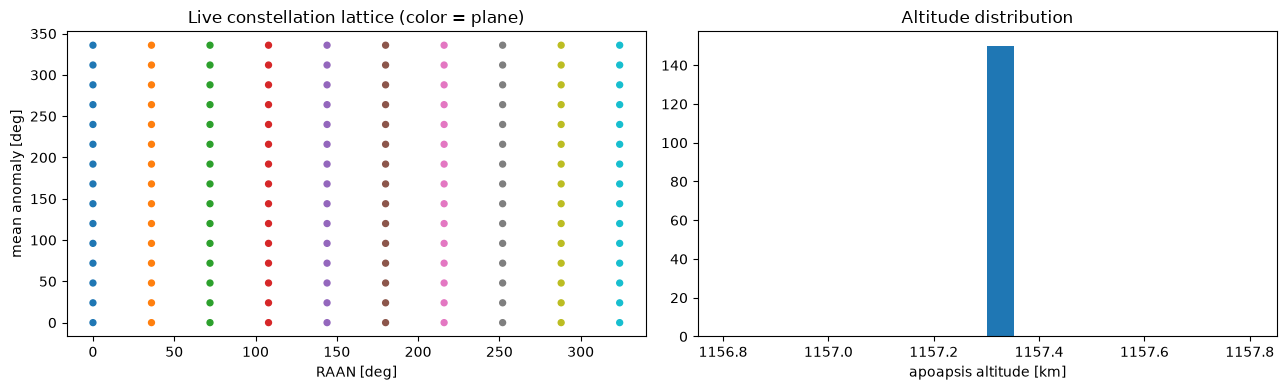

In [2]:
# === What constellation is this? (derived from the live elements) ===
from ngso_sls.constants import RE_EQ
alt_km = elems[:, 0] * (1 + elems[:, 1]) - RE_EQ
inc_deg = np.degrees(elems[:, 2])
raan_deg = np.degrees(elems[:, 3])
M_deg = np.degrees(elems[:, 5])
n_planes = len(np.unique(plane_uid))
print(f"altitude: {alt_km.min():.0f}-{alt_km.max():.0f} km | inclination: "
      f"{inc_deg.min():.1f}-{inc_deg.max():.1f} deg | {n_planes} planes x "
      f"{elems.shape[0] // max(n_planes,1)} sats")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sc = ax[0].scatter(raan_deg, M_deg, c=plane_uid, cmap="tab10", s=18)
ax[0].set_xlabel("RAAN [deg]"); ax[0].set_ylabel("mean anomaly [deg]")
ax[0].set_title("Live constellation lattice (color = plane)")
ax[1].hist(alt_km, bins=20, color="tab:blue")
ax[1].set_xlabel("apoapsis altitude [km]"); ax[1].set_title("Altitude distribution")
plt.tight_layout(); plt.show()


In [3]:
# === Service parameters FROM THE MODEL (NMTS antenna field-of-regard) ===
# Min elevation is not an SLS guess — the instance models it: ek_antenna carries
# field_of_regard (conic half-angle from boresight). For a zenith-pointed ground antenna,
# min_elevation = 90 - outer_half_angle. (azimuth_elevation_mask would refine this with
# terrain horizons; none are set in this scenario.)
EK_ANTENNA = 40
def _min_elev_from_model(prefix):
    angles = [e.antenna.field_of_regard.conic.outer_half_angle_deg
              for e in entities if getattr(e, "kind", -1) == EK_ANTENNA
              and str(e.id).startswith(prefix) and e.antenna.HasField("field_of_regard")]
    return (90.0 - float(np.median(angles))) if angles else None

MODEL_MIN_ELEV_UT = _min_elev_from_model("user-terminal")
MODEL_MIN_ELEV_GW = _min_elev_from_model("gateway")
print(f"model-derived min elevation: user links {MODEL_MIN_ELEV_UT} deg, "
      f"feeder links {MODEL_MIN_ELEV_GW} deg")


model-derived min elevation: user links 25.0 deg, feeder links 10.0 deg


In [4]:
# === Controls (notebook-01 style; constellation shape comes from NMTS, all else here) ===
from datetime import datetime, timezone
from ngso_sls.grids.aor import AORS       # Global / India / CONUS / Europe

RUN_GLOBAL   = True                        #@param {type:"boolean"}
GLOBAL_RES   = 2                           #@param {type:"integer"}  (H3: 2=~87k km2 cells)
REGION       = "India"                     #@param ["India","CONUS","Europe","Global"]
REGION_RES   = 3                           #@param {type:"integer"}  (3=~12k km2 cells)

# k-coverage: grades to COMPUTE (curves/CSV) + the headline k the MAPS show.
K_VALUES     = (1, 2, 3)                   #@param — nb01 'k values' multi-select
K_HEADLINE   = 2                           #@param — nb01 'k (min sats in view)' slider
TARGET_AVAILABILITY = 0.99                 #@param {type:"number"} — threshold line + %cells

MIN_ELEV     = MODEL_MIN_ELEV_UT or 25.0   # from the model; set a number to override
ELEV_SWEEP   = (10.0, MIN_ELEV, 40.0)      # regional elevation-mask sensitivity

# k=1 make-before-break continuity gate (nb01 'handover gate'):
MBB_GATE     = False                       #@param {type:"boolean"}
MBB_OVERLAP_S = 20.0                       #@param {type:"number"} min 2-sat overlap
REQUIRE_DIFFERENT_PLANE = False            #@param {type:"boolean"}

EPOCH_UTC    = datetime(2026, 1, 1, tzinfo=timezone.utc)
DURATION_S   = 3600.0                      #@param {type:"number"}
STEP_S       = 60.0                        #@param {type:"number"}
SHARD_RES    = 1
CHUNK_STEPS  = 10
HEX_ALPHA    = 0.8

assert K_HEADLINE in K_VALUES, "K_HEADLINE must be one of K_VALUES"
_overlap = MBB_OVERLAP_S if MBB_GATE else None
print(f"analysis: global={RUN_GLOBAL}@res{GLOBAL_RES}, region={REGION}@res{REGION_RES}, "
      f"min_elev={MIN_ELEV:.0f} deg (model), k_values={K_VALUES} (maps @ k={K_HEADLINE}), "
      f"target={TARGET_AVAILABILITY:.0%}, mbb={'on' if MBB_GATE else 'off'}, "
      f"{DURATION_S:.0f}s @ {STEP_S:.0f}s")


analysis: global=True@res2, region=India@res3, min_elev=25 deg (model), k_values=(1, 2, 3) (maps @ k=2), target=99%, mbb=off, 3600s @ 60s


In [5]:
# === Global coverage run ===
from ngso_sls.pipeline import run_coverage_h3_elements
from ngso_sls.config import TimeGrid

def _cover(aor, res_h3, min_elev):
    return run_coverage_h3_elements(
        elems, plane_uid, float(min_elev), tg, aor, cell_res=res_h3,
        shard_res=SHARD_RES, chunk_steps=CHUNK_STEPS, k_values=list(K_VALUES),
        default_k=K_HEADLINE, continuity_overlap_s=_overlap,
        require_different_plane=REQUIRE_DIFFERENT_PLANE)

def _k_report(res, label):
    for k in K_VALUES:
        av = res["availability_by_k"][k]
        print(f"  {label} k={k}: mean avail {av.mean():.3f} | "
              f"cells >= {TARGET_AVAILABILITY:.0%}: {float((av >= TARGET_AVAILABILITY).mean()):.1%}")

tg = TimeGrid(EPOCH_UTC, duration_s=DURATION_S, step_s=STEP_S)
res_global = None
if RUN_GLOBAL:
    res_global = _cover(AORS["Global"], GLOBAL_RES, MIN_ELEV)
    print(f"Global grid: {len(res_global['cells'])} cells (maps @ k={K_HEADLINE})")
    _k_report(res_global, "global")
else:
    print("RUN_GLOBAL=False — skipping")


Global grid: 5862 cells (maps @ k=2)
  global k=1: mean avail 0.923 | cells >= 99%: 87.2%
  global k=2: mean avail 0.850 | cells >= 99%: 45.0%
  global k=3: mean avail 0.478 | cells >= 99%: 18.9%


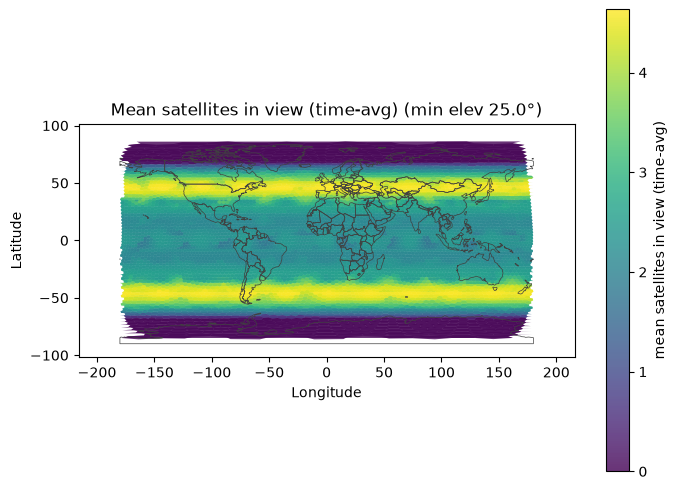

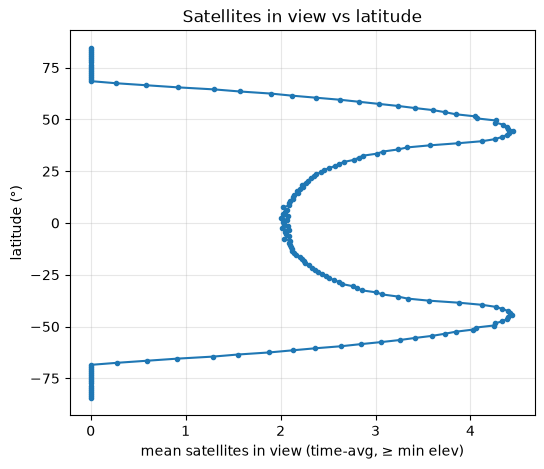

In [6]:
# === Global maps & latitude profile (maps show k = K_HEADLINE) ===
from ngso_sls.viz.plots import (plot_availability_map, plot_sats_in_view_hexmap,
                                plot_sats_in_view_vs_latitude, plot_availability_hist,
                                plot_mbb_feasible_hexmap)
if res_global is not None:
    plot_availability_map(res_global, title=f"Global availability @ k={K_HEADLINE}, "
                          f"min_elev {MIN_ELEV:.0f} deg"); plt.show()
    plot_sats_in_view_hexmap(res_global); plt.show()
    plot_sats_in_view_vs_latitude(res_global); plt.show()
    if MBB_GATE:
        plot_mbb_feasible_hexmap(res_global); plt.show()


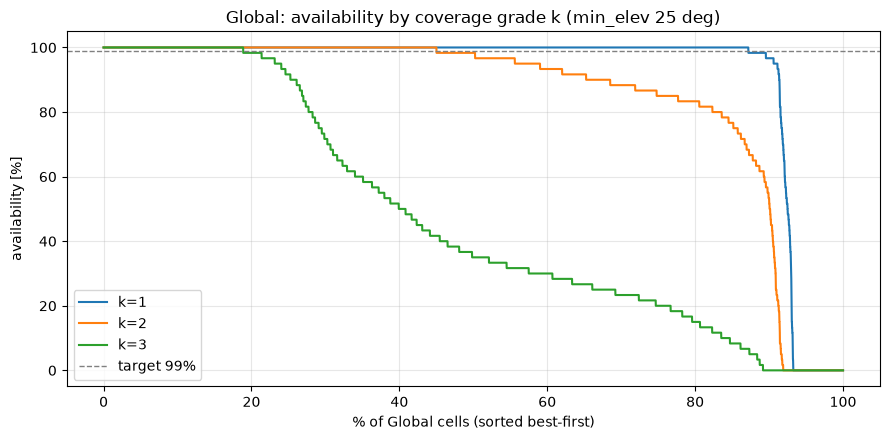

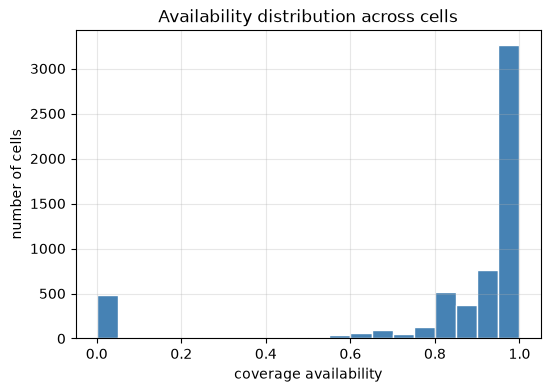

In [7]:
# === Availability curves & distribution — ALL requested k grades ===
def plot_k_curves(res, label):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for k in K_VALUES:
        av = np.sort(res["availability_by_k"][k])[::-1]
        ax.plot(np.linspace(0, 100, len(av)), av * 100, label=f"k={k}")
    ax.axhline(TARGET_AVAILABILITY * 100, color="gray", ls="--", lw=1,
               label=f"target {TARGET_AVAILABILITY:.0%}")
    ax.set_xlabel(f"% of {label} cells (sorted best-first)")
    ax.set_ylabel("availability [%]")
    ax.set_title(f"{label}: availability by coverage grade k (min_elev {MIN_ELEV:.0f} deg)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

if res_global is not None:
    plot_k_curves(res_global, "Global")
    plot_availability_hist(res_global); plt.show()   # distribution @ k=K_HEADLINE


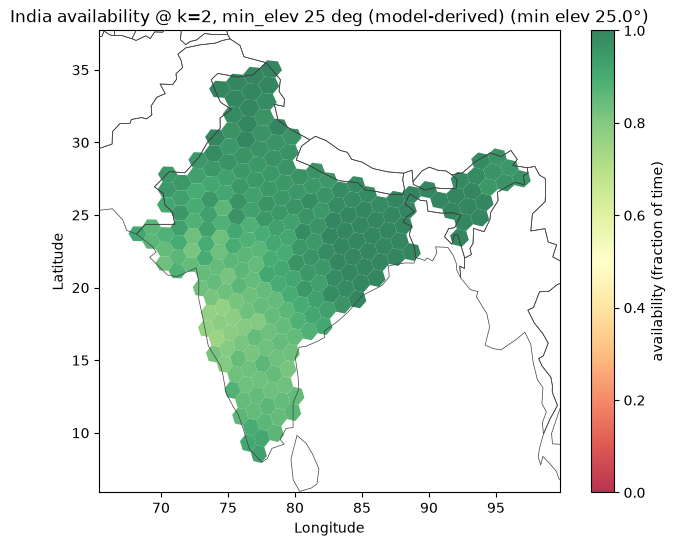

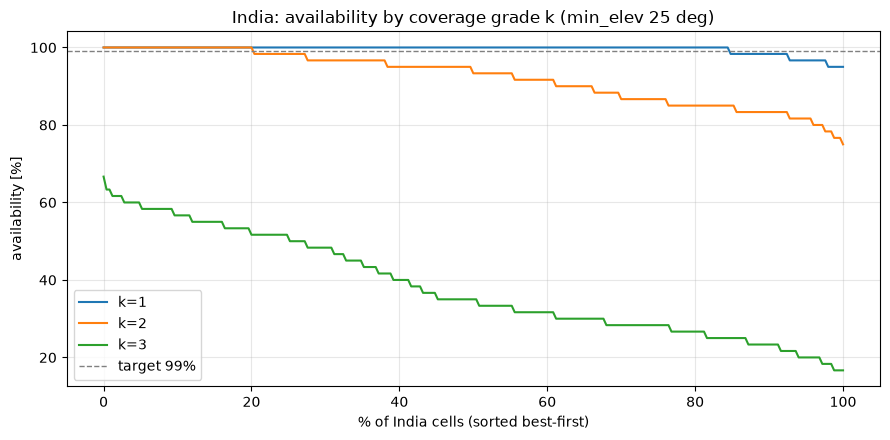

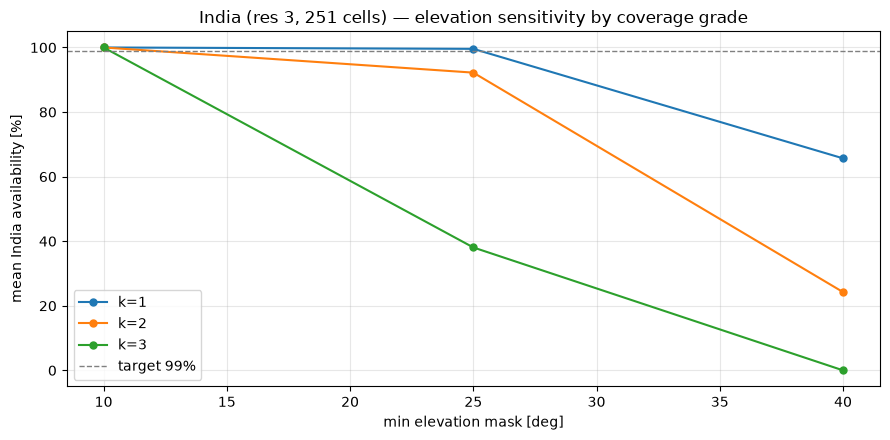

min_elev   10 deg:
  India k=1: mean avail 1.000 | cells >= 99%: 100.0%
  India k=2: mean avail 1.000 | cells >= 99%: 100.0%
  India k=3: mean avail 1.000 | cells >= 99%: 100.0%
min_elev   25 deg:
  India k=1: mean avail 0.996 | cells >= 99%: 84.5%
  India k=2: mean avail 0.922 | cells >= 99%: 20.3%
  India k=3: mean avail 0.381 | cells >= 99%: 0.0%
min_elev   40 deg:
  India k=1: mean avail 0.657 | cells >= 99%: 2.0%
  India k=2: mean avail 0.242 | cells >= 99%: 0.0%
  India k=3: mean avail 0.000 | cells >= 99%: 0.0%


In [8]:
# === Regional zoom + min-elevation sweep (all k grades) ===
from ngso_sls.viz.plots import plot_coverage_hexmap
sweep = {}
for elev in ELEV_SWEEP:
    sweep[elev] = _cover(AORS[REGION], REGION_RES, elev)
res_region = sweep[MIN_ELEV] if MIN_ELEV in sweep else list(sweep.values())[0]

plot_coverage_hexmap(res_region, title=f"{REGION} availability @ k={K_HEADLINE}, min_elev "
                     f"{MIN_ELEV:.0f} deg (model-derived)", alpha=HEX_ALPHA); plt.show()
if MBB_GATE:
    plot_mbb_feasible_hexmap(res_region, alpha=HEX_ALPHA); plt.show()
plot_k_curves(res_region, REGION)

fig, ax = plt.subplots(figsize=(9, 4.5))
for k in K_VALUES:
    means = [sweep[e]["availability_by_k"][k].mean() for e in ELEV_SWEEP]
    ax.plot(list(ELEV_SWEEP), [m * 100 for m in means], "-o", ms=5, label=f"k={k}")
ax.axhline(TARGET_AVAILABILITY * 100, color="gray", ls="--", lw=1,
           label=f"target {TARGET_AVAILABILITY:.0%}")
ax.set_xlabel("min elevation mask [deg]"); ax.set_ylabel(f"mean {REGION} availability [%]")
ax.set_title(f"{REGION} (res {REGION_RES}, {len(res_region['cells'])} cells) — "
             "elevation sensitivity by coverage grade")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

for elev in ELEV_SWEEP:
    print(f"min_elev {elev:4.0f} deg:")
    _k_report(sweep[elev], REGION)


In [9]:
# === CSV export (CSV-out convention) ===
from ngso_sls.io.csv_io import write_availability_csv, write_elements_csv
out_dir = _REPO / "outputs"; out_dir.mkdir(exist_ok=True)
manifest = {"source": SOURCE, "epoch_utc": str(EPOCH_UTC), "min_elev_deg": MIN_ELEV,
            "duration_s": DURATION_S, "step_s": STEP_S, "n_sats": int(elems.shape[0]),
            "k_values": list(K_VALUES), "default_k": K_HEADLINE,
            "target_availability": TARGET_AVAILABILITY,
            "mbb_overlap_s": _overlap, "require_different_plane": REQUIRE_DIFFERENT_PLANE,
            "snapshot_utc": datetime.now(timezone.utc).isoformat()}
if res_global is not None:
    write_availability_csv(res_global, out_dir / "live_global_availability.csv", manifest)
write_availability_csv(res_region, out_dir / f"live_{REGION.lower()}_availability.csv", manifest)
write_elements_csv(elems, [m["sat_id"] for m in built["meta"]],
                   out_dir / "live_constellation_elements.csv", manifest)
print("wrote:", *[p.name for p in out_dir.glob('live_*.csv')])


wrote: live_constellation_elements.csv live_global_availability.csv live_india_availability.csv


**Reading the results** — this is the Slice-A analysis of notebook 01, but the
constellation under test is whatever the live instance is actually flying. The 53°
inclination shows as the availability band in the global map and the sats-in-view
latitude profile (peak near ±53°, zero at the poles). The elevation sweep quantifies how
much margin the scenario has against stricter masks. Elements + availability are exported
to `outputs/` for downstream comparison against Walker presets (e.g. notebook 01 with
matched parameters).